# Zero-Shot Linking Demo

This notebook loads a released IdentityPFN checkpoint, scores a small table of toy records, and inspects the predicted adjacency matrix.

In [1]:
from pathlib import Path
import os

if not Path("identitypfn").exists() and Path("../identitypfn").exists():
    os.chdir("..")

import matplotlib.pyplot as plt
import pandas as pd

from identitypfn import load_model, nearest_neighbors, pair_review_table, top_pairs

## Toy Records

In [2]:
records = pd.DataFrame(
    [
        {
            "first_name": "Ada",
            "last_name": "Lovelace",
            "email": "ada@example.com",
            "phone": "415-555-0101",
            "city": "San Francisco",
        },
        {
            "first_name": "A.",
            "last_name": "Lovelace",
            "email": "ada@example.com",
            "phone": "+1 415 555 0101",
            "city": "SF",
        },
        {
            "first_name": "Grace",
            "last_name": "Hopper",
            "email": "grace@example.com",
            "phone": "212-555-0199",
            "city": "New York",
        },
        {
            "first_name": "Grace M",
            "last_name": "Hopper",
            "email": "g.hopper@example.com",
            "phone": "2125550199",
            "city": "NYC",
        },
        {
            "first_name": "Katherine",
            "last_name": "Johnson",
            "email": "kj@example.com",
            "phone": "703-555-0188",
            "city": "Hampton",
        },
        {
            "first_name": "Alan",
            "last_name": "Turing",
            "email": "alan@example.org",
            "phone": "020 5555 0177",
            "city": "London",
        },
    ],
    index=["r0", "r1", "r2", "r3", "r4", "r5"],
)
field_types = ["text", "text", "email", "phone", "text"]
records

,first_name,last_name,email,phone,city
r0,Ada,Lovelace,ada@example.com,415-555-0101,San Francisco
r1,A.,Lovelace,ada@example.com,+1 415 555 0101,SF
r2,Grace,Hopper,grace@example.com,212-555-0199,New York
r3,Grace M,Hopper,g.hopper@example.com,2125550199,NYC
r4,Katherine,Johnson,kj@example.com,703-555-0188,Hampton
r5,Alan,Turing,alan@example.org,020 5555 0177,London


## Load Checkpoint and Score All Pairs

In [3]:
checkpoint_path = Path(
    "results/model_checkpoints/20260715_195803_seed1337_20005214_best_step1500.pt"
)
linker = load_model(checkpoint_path, device="cpu")
scores = linker.predict_proba(records, field_types)
scores.round(3)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,r0,r1,r2,r3,r4,r5
r0,1.000,0.983,0.014,0.000,0.000,0.004
r1,0.983,1.000,0.000,0.000,0.000,0.000
r2,0.014,0.000,1.000,0.851,0.010,0.000
r3,0.000,0.000,0.851,1.000,0.001,0.000
r4,0.000,0.000,0.010,0.001,1.000,0.000
r5,0.004,0.000,0.000,0.000,0.000,1.000


## Adjacency Heatmap

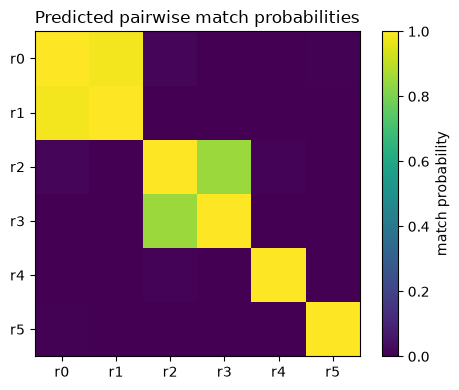

In [4]:
fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(scores, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(range(len(scores.columns)), scores.columns)
ax.set_yticks(range(len(scores.index)), scores.index)
ax.set_title("Predicted pairwise match probabilities")
fig.colorbar(image, ax=ax, label="match probability")
fig.tight_layout()

## Top Pair Search

In [5]:
top_pairs(scores, k=8)

,left_index,right_index,score
0,r0,r1,0.982556
1,r2,r3,0.850804
2,r0,r2,0.014406
3,r2,r4,0.009567
4,r0,r5,0.003978
5,r3,r4,0.000800
6,r1,r5,0.000345
7,r0,r3,0.000308


## Per-Record Nearest Neighbors

In [6]:
nearest_neighbors(scores, k=2)

,query_index,neighbor_index,rank,score
0,r0,r1,1,0.982556
1,r0,r2,2,0.014406
2,r1,r0,1,0.982556
3,r1,r5,2,0.000345
4,r2,r3,1,0.850804
5,r2,r0,2,0.014406
6,r3,r2,1,0.850804
7,r3,r4,2,0.000800
8,r4,r2,1,0.009567
9,r4,r3,2,0.000800


## Review Table

In [7]:
pair_review_table(
    scores,
    records,
    k=8,
    columns=["first_name", "last_name", "email", "phone", "city"],
).round({"score": 3})

,left_index,right_index,score,left_first_name,right_first_name,left_last_name,right_last_name,left_email,right_email,left_phone,right_phone,left_city,right_city
0,r0,r1,0.983,Ada,A.,Lovelace,Lovelace,ada@example.com,ada@example.com,415-555-0101,+1 415 555 0101,San Francisco,SF
1,r2,r3,0.851,Grace,Grace M,Hopper,Hopper,grace@example.com,g.hopper@example.com,212-555-0199,2125550199,New York,NYC
2,r0,r2,0.014,Ada,Grace,Lovelace,Hopper,ada@example.com,grace@example.com,415-555-0101,212-555-0199,San Francisco,New York
3,r2,r4,0.010,Grace,Katherine,Hopper,Johnson,grace@example.com,kj@example.com,212-555-0199,703-555-0188,New York,Hampton
4,r0,r5,0.004,Ada,Alan,Lovelace,Turing,ada@example.com,alan@example.org,415-555-0101,020 5555 0177,San Francisco,London
5,r3,r4,0.001,Grace M,Katherine,Hopper,Johnson,g.hopper@example.com,kj@example.com,2125550199,703-555-0188,NYC,Hampton
6,r1,r5,0.000,A.,Alan,Lovelace,Turing,ada@example.com,alan@example.org,+1 415 555 0101,020 5555 0177,SF,London
7,r0,r3,0.000,Ada,Grace M,Lovelace,Hopper,ada@example.com,g.hopper@example.com,415-555-0101,2125550199,San Francisco,NYC
